### Задание:
**Задача 1: EDA таблицы payments**

Изучите таблицу payments и проведите разведочный анализ данных. Для этого нужно ответить на вопросы
+ определите сколько в таблице строк  и столбцов
+ выведите среднее, медиану, минимум, максимум и стандартное отклонение для колонки sum_payment
+ выведите количество нуллов. Можем ли мы заполнить нуллы значениями
+ выведите количество выбросов. Очистите данные от выбросов
+ постройте график с распределением sum_payment (sns.histplot)

**Задача 2**
Агрегируйте данные по пользователю и месяцу

**Задача 3**
Рассчитайте выручку и количество тренировок в динамике по месяцам. Постройте графики

**Задача 4** 
К вам обратился отдел ценообразования, они хотят запустить новые безлимитные контракты на занятия на 3/6/12 месяцев с фиксированной стоимостью вне зависимости от фактического количества тренировок. Чтобы решить, какие цены установить на такие контракты, вас просят рассчитать LTR — сколько денег в среднем приносит нам сейчас 1 пользователь за все время посещений, и LT — сколько месяцев в среднем пользователь тренируется. 

**Задача 5**
Оцените эффект от маркетинговой акции для выручки и для прибыли (при условии, что переменные косты на 1 занятие равны 800 руб. для индивидуальной тренировки и 200 руб. для групповой)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
payments = pd.read_csv('payments.csv')
payments.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


### Задача 1. EDA

In [4]:
payments.shape

(35775, 4)

In [5]:
payments.dtypes

id_user            int64
training_type     object
sum_payment      float64
date              object
dtype: object

In [6]:
payments.isnull().sum()

id_user            0
training_type      0
sum_payment      715
date             357
dtype: int64

In [7]:
# Зная тип тренировки и стоимость, мы можем заполнить нулевые значения известными данными
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'group'), 'sum_payment'] =800
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv'), 'sum_payment'] =1800
payments['date'] = pd.to_datetime(payments['date'], errors = 'coerce')

In [8]:
#В мае была акция и индивидуальные тренировки стоили 1600 вместо 1800
payments.loc[(payments['sum_payment'].isnull()) & (payments['training_type'] == 'indiv') &\
             (payments['date'].dt.month ==5), 'sum_payment'] =1600

In [9]:
payments.isnull().sum()

id_user            0
training_type      0
sum_payment        0
date             357
dtype: int64

In [10]:
# У нас всего в таблице 35775 строк, из них 357 пустые, что составляет менее 1% данных. Данные строки можно удалить без ущерба для дальнейшего анализа
payments = payments[~payments['date'].isnull()]
payments.isnull().sum()

id_user          0
training_type    0
sum_payment      0
date             0
dtype: int64

In [11]:
payments['sum_payment'].describe() #Смотрим основые метрики по сумме оплат. Основное количество платежей в пределах норма от 800 до 1800 руюлей,есть выбросы.

count    35418.000000
mean      1116.398441
std        874.529319
min        800.000000
25%        800.000000
50%        800.000000
75%       1600.000000
max      18000.000000
Name: sum_payment, dtype: float64

In [12]:
payments['training_type'].value_counts(normalize = True) # Смотрим распределение типов занятий: групповые 73%, индивы 27%

training_type
group    0.729318
indiv    0.270682
Name: proportion, dtype: float64

<Axes: ylabel='sum_payment'>

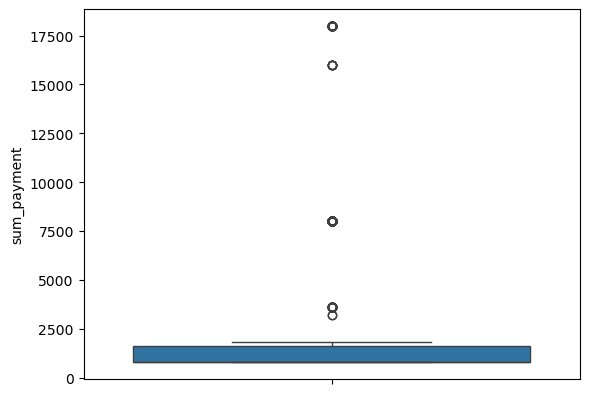

In [13]:
sns.boxplot(payments['sum_payment']) # Видим наличие выбросов по суммам платежей

In [14]:
Q1 = np.percentile(payments['sum_payment'],25)
Q3 = np.percentile(payments['sum_payment'],75)
IQR = Q3-Q1
lower_border = Q1 - 1.5*IQR
upper_border = Q3+1.5*IQR
print(lower_border, upper_border)

-400.0 2800.0


In [15]:
# Для дальнейшего анализа берем только те данные, которые находятся в пределах верхней кванлильной границы
payments_clean = payments.loc[payments['sum_payment']<upper_border].copy()
payments_clean.head()

,id_user,training_type,sum_payment,date
0,1000,indiv,1800.0,2023-03-04
1,1000,indiv,1800.0,2023-03-21
2,1000,indiv,1800.0,2023-04-03
3,1000,indiv,1800.0,2023-04-12
4,1000,indiv,1800.0,2023-04-20


In [16]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35418 entries, 0 to 35774
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id_user        35418 non-null  int64         
 1   training_type  35418 non-null  object        
 2   sum_payment    35418 non-null  float64       
 3   date           35418 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.4+ MB


Данные очищены и готовы к дальнейшему анализу

### Задача 2. Агрегация данных

In [17]:
#Добавляем столбец с месяцем оплаты для дальнейшего анализа
payments_clean['month'] = payments_clean['date'].dt.strftime('%Y-%m')
payments_clean.head()

,id_user,training_type,sum_payment,date,month
0,1000,indiv,1800.0,2023-03-04,2023-03
1,1000,indiv,1800.0,2023-03-21,2023-03
2,1000,indiv,1800.0,2023-04-03,2023-04
3,1000,indiv,1800.0,2023-04-12,2023-04
4,1000,indiv,1800.0,2023-04-20,2023-04


In [44]:
#Строим сводную таблицу, которая будет показвать сколько у пользователя было групповых и индивидуальных тренировок с суммами оплат
pivot_pay = pd.pivot_table(payments_clean,\
                           index = ['id_user', 'month'],\
                           columns = 'training_type' , \
                           values='sum_payment', \
                           aggfunc=['count', 'sum'], \
                           fill_value=0).reset_index()


In [43]:
pivot_pay.head()

,id_user,month,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_month,max_month
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [20]:
pivot_pay.columns = ['id_user','month', 'cnt_group', 'cnt_indiv', 'sum_group', 'sum_indiv'] #Корректно переименовываем столбцы
pivot_pay['cnt_total']= pivot_pay['cnt_group'] + pivot_pay['cnt_indiv'] #Добавляем стоблбец с общим кол-вом тренировок в месяц
pivot_pay['sum_total']= pivot_pay['sum_group'] + pivot_pay['sum_indiv']#Добавляем стоблбец с общей суммой оплат в месяц по каждому пользователю
pivot_pay.head()

,id_user,month,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0


### Задача 3. Анализ выручки и количества тренировок

In [21]:
#Делаем сводную таблицу по месяцам с суммарным количеством тренировок (групповых и индив) и суммарными оплатами по всем пользователям
pay_gr = pivot_pay.groupby('month')[['cnt_group', 'cnt_indiv', 'cnt_total', 'sum_group', 'sum_indiv', 'sum_total']].\
    sum().reset_index()
pay_gr

,month,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total
0,2023-01,1787,856,2643,1437600.0,1540800.0,2978400.0
1,2023-02,1804,920,2724,1447200.0,1656000.0,3103200.0
2,2023-03,1789,872,2661,1439200.0,1569600.0,3008800.0
3,2023-04,1955,720,2675,1572800.0,1296000.0,2868800.0
4,2023-05,1541,1320,2861,1242400.0,2116400.0,3358800.0
5,2023-06,2315,680,2995,1864000.0,1224000.0,3088000.0
6,2023-07,2457,741,3198,1976800.0,1333800.0,3310600.0
7,2023-08,2474,728,3202,1988000.0,1310400.0,3298400.0
8,2023-09,2444,745,3189,1968000.0,1341000.0,3309000.0
9,2023-10,2504,724,3228,2015200.0,1303200.0,3318400.0


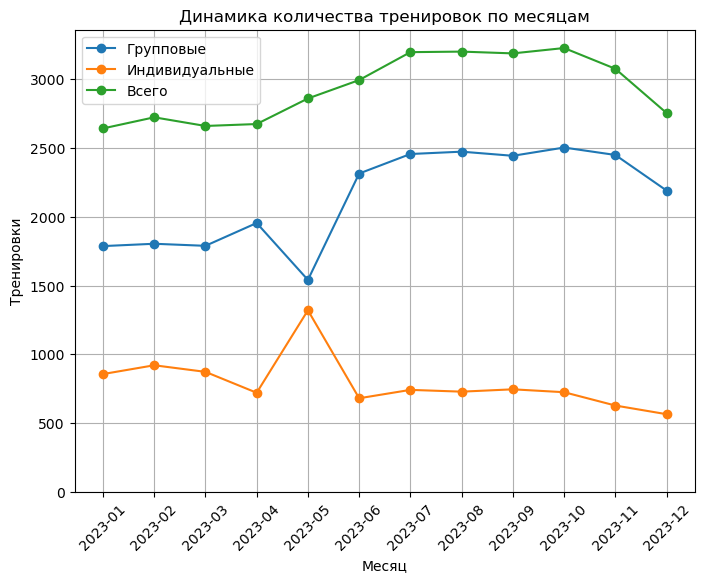

In [22]:
#Динамика тренировок
plt.figure(figsize=(8, 6)) # задаем размер графика
plt.plot(pay_gr['month'], pay_gr['cnt_group'], marker='o', label='Групповые') # рисуем линию для групповых тренировок
plt.plot(pay_gr['month'], pay_gr['cnt_indiv'], marker='o', label='Индивидуальные')#рисуем линию для инд. тренировок
plt.plot(pay_gr['month'], pay_gr['cnt_total'], marker='o', label='Всего')
plt.xlabel('Месяц') # подписываем ось х
plt.ylabel('Тренировки') # подписываем ось y
plt.title('Динамика количества тренировок по месяцам') #подписываем график
plt.legend() #добавляем легенду - где какая линия
plt.grid(True) # добавляем сетку
plt.ylim(bottom=0)  # начинаем ось Y с нуля
plt.xticks(rotation=45)  # поворот подписей на оси X
plt.show() # выводим график на экран

**Выводы и наблюдения:** Суммарно видим, что начилная с апреля количество тренировок увеличивается и падвет к концу года, начиная с ноября. Это скорее связанно с сезонностью бизнеса: люди начинают приводить тело в порядок к лету и поддерживать его, а в конце года наблюдаем спад предположительно по следующим причинам: \
- увеличивается финансовой нагрузки из-за предстоящих праздников (подарки, путешествия);
- увеличивается пул рабочих задач в большинстве сфер, не хватает времени и сил на тренировки;
- зимой подтянутое тело менее актцуально из-за большого количества одежды).\\

Если смотреть по типам тренировок, то видим, что в мае увеличивается количество индивидуальных тренирвоок при одновременном спаде количества групповых занятий. Вероятнее всего это связано с проводимой в мае акцией снижения стоимости индивидуальной тренировки до 1600 рублей. В связи с этим часть клиентов перешла с групповых тренировок на индивидуальные.

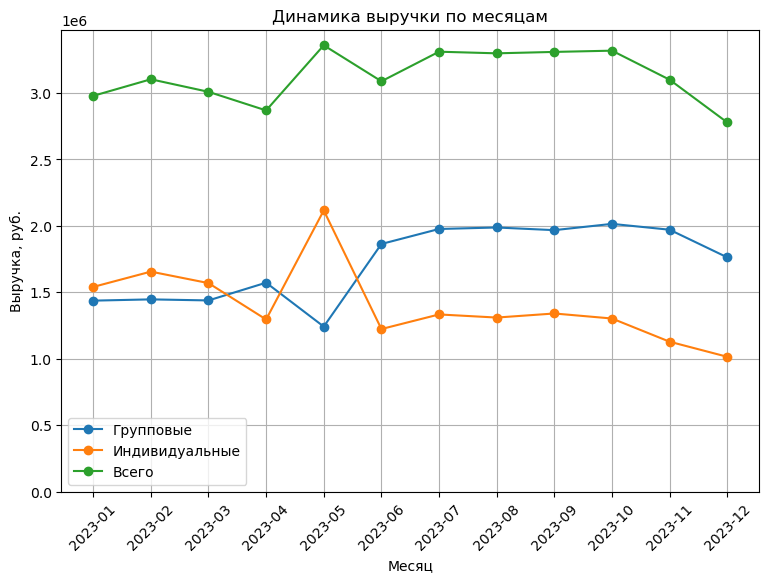

In [23]:
#Динамика выручки
plt.figure(figsize=(9, 6)) # задаем размер графика
plt.plot(pay_gr['month'], pay_gr['sum_group'], marker='o', label='Групповые') # рисуем линию для групповых тренировок
plt.plot(pay_gr['month'], pay_gr['sum_indiv'], marker='o', label='Индивидуальные')#рисуем линию для инд. тренировок
plt.plot(pay_gr['month'], pay_gr['sum_total'], marker='o', label='Всего')
plt.xlabel('Месяц') # подписываем ось х
plt.ylabel('Выручка, руб.') # подписываем ось y
plt.title('Динамика выручки по месяцам') #подписываем график
plt.legend() #добавляем легенду - где какая линия
plt.grid(True) # добавляем сетку
plt.ylim(bottom=0)  # начинаем ось Y с нуля
plt.xticks(rotation=45)  # поворот подписей на оси X
plt.show() # выводим график на экран

**Выводы и наблюдения:** По графику видим, что в мае выросла выруска по индивидуальным занятиям и упала по групповым. Связваем это с проводимой в мае маркетинговой акцией. Несмотря на просадку по выручке по групповым занятиям, суммарная выручка в мае выросла в связи с проведением акции. Насколько акция была успешной будем ниже судить анализу прибыли, а не выручки.

### Задача 4. Считаем LT и LTR

In [24]:
#добавляем в таблицу с данными по пользователю и месяцам столбы с первым и последним месяцами
pivot_pay['min_month'] = pivot_pay.groupby('id_user')['month'].transform('min')
pivot_pay['max_month'] = pivot_pay.groupby('id_user')['month'].transform('max')
pivot_pay.head()


,id_user,month,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_month,max_month
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [25]:
# Почсчитаем среднюю суммарную выручку по клиенту за все время его жизни и медиану
pay_ltr = pivot_pay.groupby('id_user').agg( ltr = ('sum_total', 'sum')).reset_index()
print (round(pay_ltr['ltr'].mean(),2))    
print (round(pay_ltr['ltr'].median(),2))    

38720.95
30600.0


Видим, что медиана меньше среднего значения на 8 720 рублей. Посмострим на само распределение значений LTR

<Axes: xlabel='ltr', ylabel='Count'>

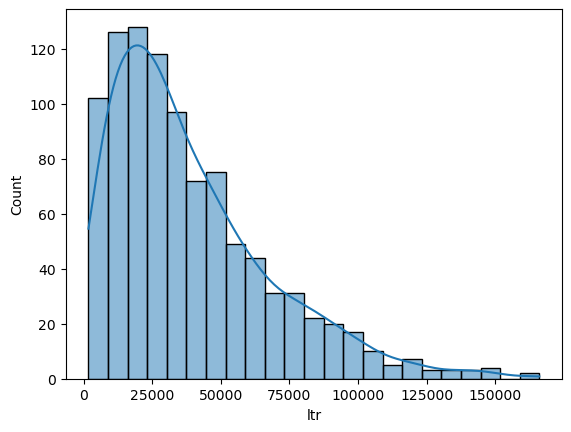

In [26]:
sns.histplot(pay_ltr['ltr'], kde = True)

По распредленеию видим тяжелый правый хвост, то есть у нас есть пользователи, у которых достаточно большой LTR: или они часто занимаются, или покупают много индивидуальных тренировок или достаточно долго ходят к нам. Поэтому получается такая большая разница между средним и медианой, и больше мы доверяем медиане.

Также наши данные обрываются на декабре 2023 года, поэтому мы можем недооценивать LTR пользователей, которые пришли в октябре, ноябре и продолжают заниматься после декабря. Исключим их из дальнейшего анализа.

In [27]:
clean_pay = pivot_pay.loc[pivot_pay['max_month']!='2023-12']
print(len(pivot_pay))
print(len(clean_pay))

5293
2558


In [ ]:
Отсеклось примерно половина пользователей, по оставшейся половине посмотрим какой выйде средний LTR.

In [28]:
clean_ltr = clean_pay.groupby('id_user').agg( ltr = ('sum_total', 'sum')).reset_index()
print (round(clean_ltr['ltr'].mean(),2))    
print (round(clean_ltr['ltr'].median(),2))  

32637.21
25600.0


Видим что LTR уменьшился и по среднему значению и по медиане, хотя мы вроде бы удалили пользователей которые еще занимаются, мы получили результаты меньше. Судя по всему мы столкнулись с ошибкой отбора. То есть в выборке остались пользователи, которые быстро бросают и не попадают пользователи, которые продолжают заниматься. Чтобы хотя бы частично минимизировать потери данных от этой ошибки, ограничим выборку не по последнему месяцу, а по месяцу начала и возьмем только первые шесть месяцев.

In [29]:
clean_pay2 = pivot_pay.loc[pivot_pay['min_month'].isin(['2023-01','2023-02','2023-03','2023-04','2023-05','2023-06'])]
clean_pay2.head()

,id_user,month,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_month,max_month
0,1000,2023-03,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
1,1000,2023-04,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12
2,1000,2023-05,0,4,0.0,6400.0,4,6400.0,2023-03,2023-12
3,1000,2023-06,0,2,0.0,3600.0,2,3600.0,2023-03,2023-12
4,1000,2023-07,0,4,0.0,7200.0,4,7200.0,2023-03,2023-12


In [30]:
print(len(pivot_pay))
print(len(clean_pay2))

5293
4770


In [ ]:
В данном отборе мы теряем уже меньшее количество данных. остается 4770 из 5293 записей

In [47]:
#Расчиатаем LTR по отфильтрованныи данным
clean_ltr2 = clean_pay2.groupby('id_user').agg(ltr = ('sum_total', 'sum')).reset_index()
print (round(clean_ltr2['ltr'].mean(),2))    
print (f'Средний совокупный доход от одного клиента за все время - {round(clean_ltr2['ltr'].median(),2)}')  

42423.43
Средний совокупный доход от одного клиента за все время - 35000.0


In [32]:
# Расчитаем среднее время жизни одного клиента
lt = clean_pay2.groupby('id_user').agg( nmonth = ('id_user', 'count')).reset_index()
print(lt['nmonth'].mean())

6.007556675062972


**Передаем итоговую инофрмацию в отдел ценообразования**:
LTR - 35 000 рублей, LT - 6 месяцев

### Задача 5. Анализ маркетинговой акции

In [34]:
#Фактическое количество тренировок по месяцам
cnt_ind_apr = pay_gr.loc[pay_gr['month'] == '2023-04', 'cnt_indiv'].iloc[0]
cnt_gr_apr = pay_gr.loc[pay_gr['month'] == '2023-04', 'cnt_group'].iloc[0]
cnt_ind_may = pay_gr.loc[pay_gr['month'] == '2023-05', 'cnt_indiv'].iloc[0]
cnt_gr_may = pay_gr.loc[pay_gr['month'] == '2023-05', 'cnt_group'].iloc[0]
cnt_ind_june = pay_gr.loc[pay_gr['month'] == '2023-06', 'cnt_indiv'].iloc[0]
cnt_gr_june = pay_gr.loc[pay_gr['month'] == '2023-06', 'cnt_group'].iloc[0]


In [35]:
# Фактическая выручка за май
rev_fact_may = pay_gr.loc[pay_gr['month']=='2023-05', 'sum_total'].iloc[0]

In [36]:
# Гипотетическая выручка за май при обычной стоимости индив тренировок
rev_hyp_may = (cnt_ind_apr + cnt_ind_june)*0.5*1800 + (cnt_gr_apr + cnt_gr_june)*0.5*800

In [49]:
print(f'Фактическая выручка за май - {rev_fact_may} рублей')
print(f'Гипотетическая выручка за май - {rev_hyp_may} рублей')

Фактическая выручка за май - 3358800.0 рублей
Гипотетическая выручка за май - 2968000.0 рублей


In [50]:
print(f"Прирост выручки из-за проведения акции составил: {rev_fact_may-rev_hyp_may} руб.")

Прирост выручки из-за проведения акции составил: 390800.0 руб.


In [39]:
#Фактическая прибыль за май 
prof_fact_may = pay_gr.loc[pay_gr['month']=='2023-05', 'cnt_indiv'].iloc[0]*(1600-800)+\
                pay_gr.loc[pay_gr['month']=='2023-05', 'cnt_group'].iloc[0]*(800-200)



In [40]:
# Гипотетическая прибыль за май
prof_hyp_may = (cnt_ind_apr + cnt_ind_june)*0.5*(1800-800) + (cnt_gr_apr + cnt_gr_june)*0.5*(800-200)

In [51]:
print(f'Фактическая прибыль за май - {prof_fact_may}')
print(f'Гипотетичсеская прибыль за май - {prof_hyp_may}')

Фактическая прибыль за май - 1980600
Гипотетичсеская прибыль за май - 1981000.0


In [42]:
print(f"Прирост прибыли из-за проведения акции составил: {prof_fact_may-prof_hyp_may} руб.")

 Прирост прибыли из-за проведения акции составил: -400.0 руб.


По анализу маркетинговой акции можно сделать вывод: несмотря на увеличение выручки в мае месяце, акция не принесла желаемого эффекта в увеличении прибыли. Убыток от проведения акции составил 400 рублей.